Fundamentals of Deep Learning Models

# Lab 05-2: Convolutional Neural Networks
## Exercise: Predicting MNIST digits

This exercise builds a simple **CNN for handwritten digit classification** on the MNIST dataset,
combining the convolution and pooling operations from Lab 05-1 with a fully connected output layer.
The model architecture follows the principles in Sections 5.1–5.6:
Conv (Section 5.3) → ReLU → MaxPool (Section 5.4) → Conv → ReLU → GlobalPool → Dense → Softmax.
Training uses optimizers from Chapter 4 (SGD, Momentum, Adam, etc.) and weight initialization
schemes (Xavier, He) from Section 4.4.

### Prepare MNIST dataset

The MNIST handwritten digit dataset contains 60,000 training and 10,000 test images of size 28×28.
Source: http://yann.lecun.com/exdb/mnist/ (public domain for research use).

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

NumPy version: 2.0.2
TensorFlow version: 2.19.0
Matplotlib version: 3.10.0


In [2]:
(X_train_org, y_train_num), (X_test_org, y_test) = tf.keras.datasets.mnist.load_data()

# Digits data has range of [0,255], which often lead too big exponential values
# so make them normal distribution of [0,1] with the sklearn package, or you can just divide them by 255
X_train = np.expand_dims(X_train_org / 255, -1)
X_test = np.expand_dims(X_test_org / 255, -1)

n_classes = 10

# Transform Nx1 Y vector to Nx10 answer vector, so that we can perform one-to-all classification
y_train = np.zeros((y_train_num.shape[0], 10))
for i in range(n_classes):
    y_train[:,i] = (y_train_num == i)

# Split training dataset into training and validation
X_val = X_train[50000:60000]
y_val = y_train[50000:60000]

X_train = X_train[:50000]
y_train = y_train[:50000]

n_train = X_train.shape[0]
n_val   = X_val.shape[0]
n_test  = X_test.shape[0]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# Reduce dataset size for faster experimentation
sim_rate = 0.2

n_train = int(n_train * sim_rate)
n_val   = int(n_val * sim_rate)
n_test  = int(n_test * sim_rate)

X_train, y_train = X_train[:n_train], y_train[:n_train]
X_test, y_test = X_test[:n_test], y_test[:n_test]
X_val, y_val = X_val[:n_val], y_val[:n_val]

In [4]:
print(n_train, n_val, n_test)

10000 2000 2000


### Define utility functions

In [5]:
# Numerically stable sigmoid and softmax via TensorFlow (used for forward pass only)
from tensorflow.math import sigmoid as tf_sigmoid
from tensorflow.nn import softmax as tf_softmax

def sigmoid(x):
    x = tf_sigmoid(x)
    return x.numpy()

def softmax(x):
    x = tf_softmax(x)
    return x.numpy()

In [6]:
def create_mini_batches(X, y, batch_size=64):
    """Shuffle and split data into mini-batches (Section 4.2)."""
    rnd = np.random.permutation(len(X))
    X_batches, y_batches = X[rnd], y[rnd]
    X_mini = np.split(X_batches, np.arange(batch_size,len(X),batch_size), axis=0)
    y_mini = np.split(y_batches, np.arange(batch_size,len(X),batch_size), axis=0)
    mini_batches = zip(X_mini, y_mini)
    return mini_batches

### Show dataset information

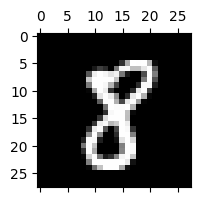

The number is 8
Dataset dimension: (10000, 28, 28, 1)
(10000, 28, 28, 1)
(10000, 10)


In [7]:
idx = np.random.randint(X_test.shape[0])
dimage = tf.reshape(X_test[idx], (28,28))
plt.figure(figsize=(2,2))
plt.gray()
plt.matshow(dimage, fignum=0)
plt.show()

print('The number is', y_test[idx])
print('Dataset dimension:', X_train.shape)
# Test code here
print(X_train.shape)
print(y_train.shape)

### Simple CNN for digit classification

Prepare convolution: im2col and col2im (from Lab 05-1)

In [ ]:
def im2col(x_img, flt_h, flt_w, stride_h=1, stride_w=1, padding_h=1, padding_w=1):
    x_b, x_h, x_w, x_c = x_img.shape
    p_h = padding_h
    p_w = padding_w

    ### START CODE HERE ###

    # Zero-pad the input along spatial dimensions (Section 5.2)
    p_x = None
    # Compute output spatial dimensions (Eq. 5.9)
    n_h = None
    n_w = None
    # Allocate 6D buffer for extracted patches
    t_col = None

    # Extract each local patch from the padded input
    for i in range(n_h):
        h = i * stride_h
        h_l = h + flt_h
        for j in range(n_w):
            w = j * stride_w
            w_l = w + flt_w
            t_col[:, i, j, :, :, :] = None

    # Reshape to 2D: (b*n_h*n_w, f_h*f_w*x_c) (Section 5.7, Fig. 5.18)
    x_col = None

    ### END CODE HERE ###

    return x_col

def col2im(x_col, x_shape, flt_h=1, flt_w=1, stride_h=1, stride_w=1, padding_h=1, padding_w=1):
    x_b, x_h, x_w, x_c = x_shape
    p_h = padding_h
    p_w = padding_w

    ### START CODE HERE ###

    # Compute output spatial dimensions (Eq. 5.9)
    n_h = None
    n_w = None
    # Reshape 2D column matrix back to 6D patch buffer
    r_col = None
    # Allocate padded image buffer
    p_img = None

    # Place patches back into spatial positions
    for i in range(0, n_h, flt_h):
        h = i * stride_h
        h_l = h + flt_h
        for j in range(0, n_w, flt_w):
            w = j * stride_w
            w_l = w + flt_w
            p_img[:, h:h_l, w:w_l, :] = None

    # Remove padding to restore original spatial size
    x_img = None

    ### END CODE HERE ###

    return x_img

Define dense layer class (from Lab 04-3)

In [ ]:
class myDenseLayer:
    def __init__(self, n_out, n_in):
        self.weight = np.empty((n_out, n_in))
        self.bias = np.zeros((n_out))
        self.saved_x = None

    def forward(self, x):       # x: (b, n_in)

        ### START CODE HERE ###

        # Save input for backward pass
        self.saved_x = None
        # Linear transformation: z = W @ x^T + b (Section 3.6, forward propagation)
        x_lin = None

        ### END CODE HERE ###

        return x_lin

    def backward(self, x):      # x: dJ/dz (b, n_out)

        ### START CODE HERE ###

        # Weight gradient: dJ/dW = (dJ/dz)^T @ x_in / b (Eq. 3.27)
        dw = None
        # Bias gradient: dJ/db = sum(dJ/dz) / b (Eq. 3.27)
        db = None
        # Propagate gradient to previous layer: dJ/da = dJ/dz @ W (Eq. 3.26)
        wdJdz = None

        ### END CODE HERE ###

        return dw, db, wdJdz

Define convolution layer class (from Lab 05-1)

In [ ]:
class myConv2DLayer:
    def __init__(self, n_out, flt_h, flt_w, n_in, stride=1, padding=True):
        self.weight = np.empty((n_out, flt_h, flt_w, n_in))
        self.bias = np.zeros((n_out,))
        self.f_h = flt_h
        self.f_w = flt_w
        self.f_c = n_out          # C_O: number of output channels
        self.f_i = n_in           # C_I: number of input channels
        self.s_h = stride
        self.s_w = stride
        self.p_h = flt_h // 2 if padding else 0
        self.p_w = flt_w // 2 if padding else 0
        self.saved_x = None

    def forward(self, x):
        """Forward propagation: z = conv(x, w) + b (Eq. 5.4)"""
        x_b, x_h, x_w, _ = x.shape

        ### START CODE HERE ###

        # Save input for backward pass
        self.saved_x = None
        # Compute output spatial dimensions (Eq. 5.9)
        x_h = None
        x_w = None
        # Rearrange input patches into columns (Section 5.7, im2col)
        c_img = None
        # Reshape filter to 2D: (C_O, F_H*F_W*C_I)
        c_wgt = None
        # Matrix multiply and add bias: cross-correlation as matmul (Eq. 5.4)
        c_lin = None
        # Reshape result to 4D output tensor
        x_lin = None

        ### END CODE HERE ###

        return x_lin

    def backward(self, x):
        """Backward propagation for convolution (Eqs. 5.5–5.8)."""
        x_b, x_h, x_w, x_c = self.saved_x.shape

        ### START CODE HERE ###

        # Prepare dilated gradient for stride > 1 (Section 5.3, Fig. 5.10)
        st_h = None
        st_w = None
        x_gr = None
        x_gr[:, st_h::self.s_h, st_w::self.s_w, :] = x

        # Weight gradient: cross-correlation of input with dJ/dz (Eq. 5.6)
        xi_trn = None
        c_tran = None
        x_tran = None
        c_x_dz = None
        w_grad = None
        dw = None

        # Bias gradient: sum over spatial positions and batch (Eq. 5.5)
        b_grad = None
        db = None

        # Input gradient: convolution with flipped kernel (Eq. 5.8)
        c_dJdz = None
        f_wegt = None
        c_wegt = None
        w_dJda = None
        wdJdz = None

        ### END CODE HERE ###

        return dw, db, wdJdz

Pooling functions: MaxPool, AvgPool, GlobalPool (from Lab 05-1)

In [ ]:
def pooling(x_img, flt_h, flt_w, stride_h=1, stride_w=1, filter_type='max', padding=False):
    x_b, x_h, x_w, x_c = x_img.shape
    padding_h, padding_w = (flt_h//2, flt_w//2) if padding else (0, 0)

    ### START CODE HERE ###

    # Transpose and reshape to apply im2col per channel independently
    t_img = None            # (b, c, h, w)
    r_img = None
    x_col = None
    n_h = None              # Eq. 5.9
    n_w = None

    if filter_type=='max':
        # Max pooling forward (Eq. 5.13)
        pmask = None
        pmask[np.arange(x_col.shape[0]), np.argmax(x_col, axis=-1)] = 1
        pmask = None
        pmask = pmask.reshape(t_img.shape).transpose(0,2,3,1)
        x_new = None
        x_new = x_new.reshape(x_b, x_c, n_h, n_w).transpose(0,2,3,1)
    elif filter_type=='average':
        # Average pooling forward (Eq. 5.11)
        pmask = None
        x_new = None
        x_new = x_new.reshape(x_b, x_c, n_h, n_w).transpose(0,2,3,1)
    elif filter_type=='global':
        # Global average pooling forward (Section 5.4)
        pmask = None
        f_img = t_img.reshape(-1, x_h*x_w)
        x_new = None
        x_new = x_new.reshape(x_b, -1)
    else:
        print('pooling type error')

    ### END CODE HERE ###

    return x_new, pmask

Define pooling layer (from Lab 05-1)

In [ ]:
class myPoolingLayer:
    def __init__(self, flt_h, flt_w, stride_h, stride_w, p_type='max'):
        self.type = p_type
        self.f_h = flt_h
        self.f_w = flt_w
        self.s_h = stride_h
        self.s_w = stride_w
        self.mask = None

    def forward(self, x):
        x, m = pooling(x, self.f_h, self.f_w, self.s_h, self.s_w, self.type, padding=False)
        self.mask = m
        return x

    def backward(self, x):
        """Backpropagation for pooling (Eqs. 5.12, 5.14). Assumes non-overlapping pooling."""
        (img_b, img_h, img_w, img_c) = self.mask.shape

        ### START CODE HERE ###

        if self.type=='max':
            # Max pooling backward: route gradient to max positions (Eq. 5.14)
            x_eh = None
            x_ex = None
            x_gr = None
        elif self.type=='average':
            # Average pooling backward: distribute gradient uniformly (Eq. 5.12)
            x_eh = None
            x_ex = None
            x_gr = None
        elif self.type=='global':
            x_b, x_c = x.shape
            # Global pooling backward: distribute over all spatial positions
            x_ed = None
            x_eh = None
            x_ex = None
            x_gr = None

        ### END CODE HERE ###
        
        else:
            print('pooling type error in backward')
        return x_gr

Define activation function derivatives (Section 3.3, Section 3.8)

In [ ]:
def dJdz_sigmoid(wdJdz_upper, az):

    ### START CODE HERE ###

    # Sigmoid derivative: sigma(z) * (1 - sigma(z)) (Section 3.3)
    dJdz = None

    ### END CODE HERE ###

    return dJdz

def dJdz_softmax(y_hat, y):

    ### START CODE HERE ###

    # Softmax + cross-entropy gradient: y_hat - y (Eq. 3.32)
    dJdz = None

    ### END CODE HERE ###

    return dJdz

def relu(x):
    """ReLU activation: max(0, x) (Section 3.3, Eq. 3.8)"""
    return np.where(x < 0, 0, x)

def dJdz_relu(wdJdz_upper, x):
    """ReLU derivative: 1 if x > 0, else 0 (Section 3.3)"""
    return wdJdz_upper * np.where(x > 0, 1, 0)

### Create a CNN model and check matrix dimensions

Architecture: Conv1(3×3, 16) → ReLU → MaxPool(2×2) → Conv2(3×3, 32) → ReLU → GlobalPool → Dense(10) → Softmax

In [14]:
# define network
in_c = 1
h1_c = 16
h2_c = 32

l1 = myConv2DLayer(n_out=h1_c, flt_h=3, flt_w=3, n_in=in_c, stride=1, padding=True)     # (28, 28, in_c) -> (28, 28, h1_c)
p1 = myPoolingLayer(flt_h=2, flt_w=2, stride_h=2, stride_w=2, p_type='max') # (28, 28, h1_c) -> (14, 14, h1_c)
l2 = myConv2DLayer(n_out=h2_c, flt_h=3, flt_w=3, n_in=h1_c, stride=1, padding=True)    # (14, 14, h1_c) -> (14, 14, h2_c)
p2 = myPoolingLayer(flt_h=2, flt_w=2, stride_h=2, stride_w=2, p_type='global') # (14, 14, h2_c) -> (h2_c,)
l3 = myDenseLayer(n_out=n_classes, n_in=h2_c)               # (h2_c,) -> (n_classes,)

layers = [l1, p1, l2, p2, l3]

print(X_train.shape, y_train.shape)
print(l1.weight.shape, l1.bias.shape)
print(l2.weight.shape, l2.bias.shape)
print(l3.weight.shape, l3.bias.shape)

(10000, 28, 28, 1) (10000, 10)
(16, 3, 3, 1) (16,)
(32, 3, 3, 16) (32,)
(10, 32) (10,)


### Define training functions

In [ ]:
def my_forward(layers, X_in):
    l1, p1, l2, p2, l3 = layers

    ### START CODE HERE ###

    # Conv1 + ReLU (Section 5.3 forward, Section 3.3 ReLU)
    a_1 = None
    # MaxPool 2x2 (Section 5.4)
    p_1 = None
    # Conv2 + ReLU
    a_2 = None
    # Global average pooling (Section 5.4)
    p_2 = None
    # Dense + Softmax for classification (Section 3.4, Eq. 3.13)
    a_3 = None

    ### END CODE HERE ###

    return a_1, a_2, a_3

def my_backward(layers, a_1, a_2, a_3, y_true):
    l1, p1, l2, p2, l3 = layers

    ### START CODE HERE ###

    # Output layer gradient: softmax-CE simplified form (Eq. 3.32)
    dw_3, db_3, wdJdz_3 = None
    # Global pooling backward (Section 5.4)
    dJdp_2              = None
    # Conv2 backward through ReLU (Eqs. 5.5–5.8)
    dw_2, db_2, wdJdz_2 = None
    # MaxPool backward (Eq. 5.14)
    dJdp_1              = None
    # Conv1 backward through ReLU (Eqs. 5.5–5.8)
    dw_1, db_1, _       = None

    ### END CODE HERE ###

    d_1 = [dw_1, db_1]
    d_2 = [dw_2, db_2]
    d_3 = [dw_3, db_3]
    return d_1, d_2, d_3

def my_loss(layers, X_in, y_true): # defined for validation and testing
    l1, p1, l2, p2, l3 = layers

    ### START CODE HERE ###

    a_1 = None
    p_1 = None
    a_2 = None
    p_2 = None
    a_3 = None
    # Cross-entropy loss: J = -mean(sum(y * log(y_hat))) (Eq. 3.16)
    loss = None
    # Classification accuracy
    equl = None
    acc = None

    ### END CODE HERE ###

    return loss, acc

def my_predict(layers, X_in):
    l1, p1, l2, p2, l3 = layers

    ### START CODE HERE ###

    a_1 = None
    p_1 = None
    a_2 = None
    p_2 = None
    a_3 = None
    pred = None

    ### END CODE HERE ###

    return pred

### Define various optimizers (Section 4.2–4.3)

In [ ]:
class myOptParam:
    def __init__(self, w_shape):

        # Previous delta values for momentum optimizer
        self.W_dt = np.zeros(w_shape)
        self.B_dt = np.zeros(w_shape[0])
        # Variables for other optimizers
        self.W_mt = np.zeros(w_shape)
        self.B_mt = np.zeros(w_shape[0])
        self.W_vt = np.zeros(w_shape)
        self.B_vt = np.zeros(w_shape[0])
        # Variable for Adam optimizer
        self.iter = 0

def my_optimizer(lyr, opt, W_grad, B_grad, solver='sgd', learning_rate=0.01, iter=1):
    epsilon = 1e-8  # arbitrary small number
    alpha = eta = learning_rate

    if iter==0:
        print('iteration should start from 1.')

    # optimizer routines
    if  solver=='sgd':
        W_dlt = alpha * W_grad
        B_dlt = alpha * B_grad
    elif solver=='momentum':
        gamma = 0.9               # default setting
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    elif solver=='adagrad':
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    elif solver=='rmsprop':
        beta2 = 0.9               # default setting
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    elif solver=='adam':
        beta1, beta2 = 0.9, 0.99  # default setting
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    else:
        print('optimizer error')

    # Adjust weight
    lyr.weight = lyr.weight - W_dlt
    lyr.bias = lyr.bias - B_dlt

    return

#### Create optimizer parameters

In [17]:
o1 = myOptParam(l1.weight.shape)
o2 = myOptParam(l2.weight.shape)
o3 = myOptParam(l3.weight.shape)

### Initialize weights (Section 4.4)

In [18]:
def my_initializer(lyr, pdf='normal'):
    """Weight initialization (Section 4.4: Xavier/He initialization)."""
    w_shape = lyr.weight.shape

    if   len(w_shape)==2:
        fan_out, fan_in = w_shape
    elif len(w_shape)==4:
        fan_out, fan_in = w_shape[0], w_shape[1] * w_shape[2] * w_shape[3]
    else:
        print('parameter shape error')

    if pdf=='normal':
        lyr.weight = np.random.randn(*w_shape)
    elif pdf=='uniform':
        lyr.weight = np.random.uniform(-1, 1, size=w_shape)
    elif pdf=='xavier_normal':           # Var = 2/(fan_out + fan_in) (Section 4.4)
        lyr.weight = np.random.randn(*w_shape) * np.sqrt(2/(fan_out + fan_in))
    elif pdf=='xavier_uniform':
        a = np.sqrt(6 / (fan_out + fan_in))
        lyr.weight = np.random.uniform(-a, a, size=w_shape)
    elif pdf=='he_normal':               # Var = 2/fan_in (Section 4.4)
        lyr.weight = np.random.randn(*w_shape) * np.sqrt(2/fan_in)
    elif pdf=='he_uniform':
        a = np.sqrt(6 / fan_in)
        lyr.weight = np.random.uniform(-a, a, size=w_shape)
    else:
        print('initializer error')
    return

# Initialize weights using He normal (recommended for ReLU, Section 4.4)
weight_init = 'he_normal'

my_initializer(l1, pdf=weight_init)
my_initializer(l2, pdf=weight_init)
my_initializer(l3, pdf=weight_init)

### Training the CNN model

In [19]:
# tqdm library shows loop progress
RunningInCOLAB = 'google.colab' in str(get_ipython())
if not RunningInCOLAB:
    from tqdm import tqdm
else:
    from tqdm.notebook import tqdm

batch_size = 64
steps = np.ceil(len(X_train) / batch_size)
print(steps)

157.0


In [20]:
# optimizer settings are: 'sgd', 'momentum', 'adagrad', 'rmsprop', 'adam'
# alpha is learning rate
optimizer ='sgd'
alpha = 0.05
n_epochs = 20

start_t = time.time()
history = {'loss':[], 'acc':[], 'val_loss':[], 'val_acc':[]}

loss_J, acc_J = my_loss(layers, X_train[:n_val], y_train[:n_val])
loss_V, acc_V = my_loss(layers, X_val, y_val)

for epoch in range(n_epochs):

    batches = create_mini_batches(X_train, y_train, batch_size=64)

    pbar = tqdm(batches, total=steps)
    pbar.set_description('Epoch:%2d' % (epoch+1))

    for one_batch in pbar:
        X_mini, y_mini = one_batch
        batch_len = X_mini.shape[0]  # last batch might have different length

        # Forward Path
        a_1, a_2, a_3 = my_forward(layers, X_mini)

        # Backward Path
        d_1, d_2, d_3 = my_backward(layers, a_1, a_2, a_3, y_mini)

        dw_1, db_1 = d_1
        dw_2, db_2 = d_2
        dw_3, db_3 = d_3

        lr = alpha if epoch<15 else alpha/5

        # Update weights and biases
        my_optimizer(l1, o1, dw_1, db_1, solver=optimizer, learning_rate=lr)
        my_optimizer(l2, o2, dw_2, db_2, solver=optimizer, learning_rate=lr)
        my_optimizer(l3, o3, dw_3, db_3, solver=optimizer, learning_rate=lr)

        pbar.set_postfix({'loss':loss_J, 'acc':acc_J, 'val_loss':loss_V, 'val_acc':acc_V})

    loss_J, acc_J = my_loss(layers, X_train[:n_val], y_train[:n_val])
    loss_V, acc_V = my_loss(layers, X_val, y_val)

    history['loss'].append(loss_J), history['acc'].append(acc_J)
    history['val_loss'].append(loss_V), history['val_acc'].append(acc_V)

elapsed_t = time.time() - start_t
print(f'Epoch: {epoch+1:4d}, Elapsed_t: {elapsed_t:4.2f}s loss: {loss_J:10.8f}'+
      f' acc: {acc_J:10.8f} - val_loss: {loss_V:10.8f} val_acc: {acc_V:10.8f}')


  0%|          | 0/157.0 [00:00<?, ?it/s]

  0%|          | 0/157.0 [00:00<?, ?it/s]

  0%|          | 0/157.0 [00:00<?, ?it/s]

  0%|          | 0/157.0 [00:00<?, ?it/s]

  0%|          | 0/157.0 [00:00<?, ?it/s]

...

  0%|          | 0/157.0 [00:00<?, ?it/s]

  0%|          | 0/157.0 [00:00<?, ?it/s]

  0%|          | 0/157.0 [00:00<?, ?it/s]

  0%|          | 0/157.0 [00:00<?, ?it/s]

Epoch:   20, Elapsed_t: 965.50s loss: 1.52439536 acc: 0.49850000 - val_loss: 1.56353973 val_acc: 0.47950000


### Plot loss and accuracy

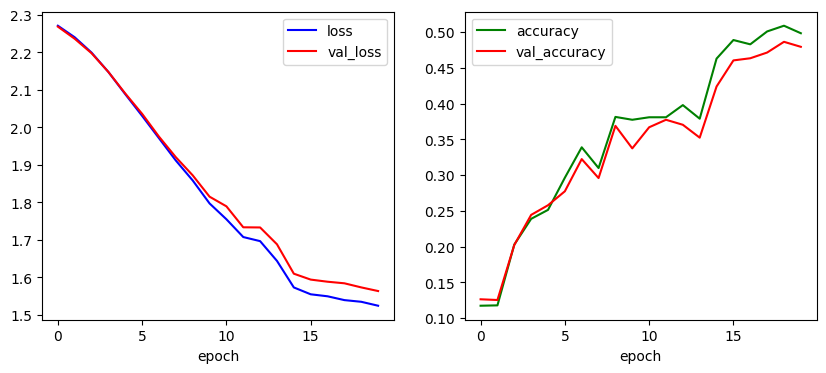

In [21]:
# plot loss and accuracy
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['loss'], 'b-', label='loss')
plt.plot(history['val_loss'], 'r-', label='val_loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['acc'], 'g-', label='accuracy')
plt.plot(history['val_acc'], 'r-', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()

plt.show()

### Evaluate model performance

In [22]:
from sklearn.metrics import accuracy_score

y_pred = my_predict(layers, X_test)

accuracy_score(y_pred, y_test)

0.45

### Test model with a random sample

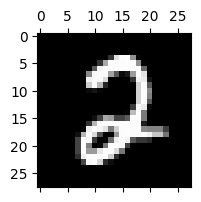

My prediction is 2
Actual number is 2


In [23]:
idx = np.random.randint(X_test.shape[0])
plt.figure(figsize=(2,2))
plt.gray()
plt.matshow(X_test_org[idx], fignum=0)
plt.show()

X_input = np.expand_dims(X_test[idx], 0)

y_pred = my_predict(layers, X_input)

print('My prediction is ' + str(y_pred[0]))
print('Actual number is ' + str(y_test[idx]))

(c) 2026 S. W. Lee